Import libraries

In [92]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Load and preprocess dataset

In [93]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),      # ← NEW
    transforms.RandomRotation(15),              # ← Increased
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # ← NEW
    transforms.ColorJitter(brightness=0.2, contrast=0.2),     # ← NEW
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),  
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

loading dataset

In [94]:
full_train_dataset = torchvision.datasets.ImageFolder(
    root='C:/Users/Nassif/Desktop/Applied Machine Learning and Deep Learning 2/train/train', 
    transform=train_transform  
)

test_dataset = torchvision.datasets.ImageFolder(
    root='C:/Users/Nassif/Desktop/Applied Machine Learning and Deep Learning 2/test/test', 
    transform=test_transform   
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", full_train_dataset.classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Classes: ['NORMAL', 'PNEUMONIA']
Training samples: 3359
Validation samples: 840
Test samples: 621


Visualize sample images

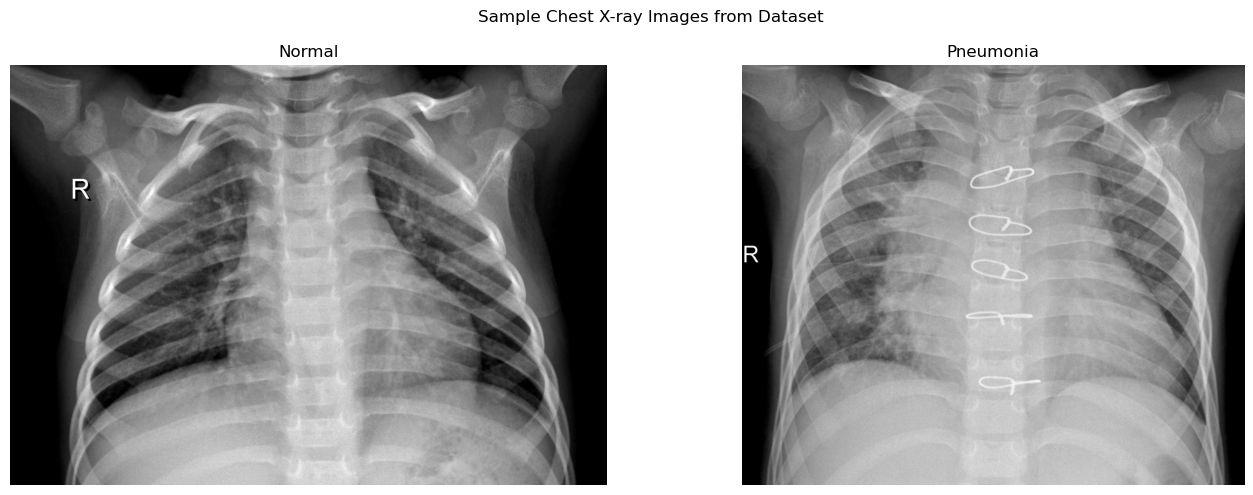

In [95]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

img1 = Image.open('C:/Users/Nassif/Desktop/Applied Machine Learning and Deep Learning 2/train/train/NORMAL/IM-0125-0001.jpeg')
img2 = Image.open('C:/Users/Nassif/Desktop/Applied Machine Learning and Deep Learning 2/train/train/PNEUMONIA/person13_bacteria_49.jpeg')

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Normal')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Pneumonia')
axes[1].axis('off')

fig.suptitle('Sample Chest X-ray Images from Dataset')
plt.tight_layout()
plt.show()

Basic SNN

In [99]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 56 * 56, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model = BasicSNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)




In [100]:

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, device='cpu', patience=5):
    best_val_acc = 0
    patience_counter = 0
    
    # ... your existing training loop ...
    
    for epoch in range(epochs):
        # ... your training code ...
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')  # Save best
        else:
            patience_counter += 1
            
        print(f'Epoch {epoch+1}: Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | Best: {best_val_acc:.2f}%')
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

In [101]:
def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Reshape the input to match what the model expects
            batch_size = inputs.size(0)
            
            # Option 1: Resize the images to 64x64 (since 64x64x1 = 4096)
            inputs = torch.nn.functional.interpolate(inputs, size=(64, 64), mode='bilinear', align_corners=False)
            inputs = inputs.view(batch_size, -1)  # Flatten to [batch_size, 4096]
            
           
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f'Accuracy on test set: {100 * correct / total:.2f}%')
    
# Now call the function
evaluate_model(model, test_loader, device, class_names)

Accuracy on test set: 62.32%


In [44]:
print("Model:", "Basic SNN")

Model: Basic SNN


Basic CNN

In [102]:
class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))   # 112 -> 56
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [103]:
basic_cnn = BasicCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(basic_cnn.parameters(), lr=0.001)

train_model(basic_cnn, train_loader, val_loader, criterion, optimizer, epochs=10, device=device)

NameError: name 'val_acc' is not defined

In [61]:
def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            
            # Reshape data if it's flattened
            if len(data.shape) == 2:  # If data is [batch_size, features]
                # Calculate dimensions based on your CNN architecture
                # Your CNN expects 1 channel images that start at 224x224
                height = width = int(math.sqrt(data.shape[1]))  # Assuming square images
                data = data.view(-1, 1, height, width)
            
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    accuracy = correct / total
    
    # If class_names is provided, print classification report
    if class_names is not None:
        print(classification_report(all_targets, all_preds, target_names=class_names))
        
    return accuracy

evaluate_model(basic_cnn, test_loader, device, class_names)    

              precision    recall  f1-score   support

      NORMAL       0.52      0.06      0.11       231
   PNEUMONIA       0.63      0.97      0.77       390

    accuracy                           0.63       621
   macro avg       0.58      0.51      0.44       621
weighted avg       0.59      0.63      0.52       621



0.6296296296296297

Improved SNN

In [62]:
class ImprovedSNN(nn.Module):
    def __init__(self):
        super(ImprovedSNN, self).__init__()
        self.fc1 = nn.Linear(224 * 224, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.drop1 = nn.Dropout(0.4)

        self.fc2 = nn.Linear(512, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.drop2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        return x

In [63]:
improved_snn = ImprovedSNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(improved_snn.parameters(), lr=0.001)

train_model(improved_snn, train_loader, val_loader, criterion, optimizer, epochs=10, device=device)

In [67]:
   # If you have access to your training dataset
   for batch_idx, (data, target) in enumerate(train_loader):
       print("Unique labels in batch:", torch.unique(target))
       break  # Just check the first batch
   

Unique labels in batch: tensor([0, 1])


In [68]:
# Define class_names (replace with your actual class names)
class_names = ['NORMAL', 'PNEUMONIA']  # Modify this based on your dataset

# Call evaluate_model with all required parameters
improved_snn_acc = evaluate_model(improved_snn, test_loader, device, class_names)
print("Improved SNN Test Accuracy:", improved_snn_acc)

              precision    recall  f1-score   support

      NORMAL       0.37      1.00      0.54       231
   PNEUMONIA       1.00      0.00      0.01       390

    accuracy                           0.37       621
   macro avg       0.69      0.50      0.27       621
weighted avg       0.77      0.37      0.21       621

Improved SNN Test Accuracy: 0.37359098228663445


Improved CNN

In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import precision_score, precision_recall_fscore_support

# Define your model
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 224 -> 112
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 112 -> 56
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 56 -> 28
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)  # Removed duplicate assignment
        return x

# Define your true labels and predictions before calculating precision
# For example:
y_true = [0, 1, 0, 1]  # Replace with your actual ground truth labels
y_pred = [0, 0, 1, 1]  # Replace with your model's predictions

# Now calculate precision
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)

In [77]:
improved_cnn = ImprovedCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(improved_cnn.parameters(), lr=0.001)

train_model(improved_cnn, train_loader, val_loader, criterion, optimizer, epochs=10, device=device)

In [78]:
# Add the missing class_names parameter to the function call
improved_cnn_acc = evaluate_model(improved_cnn, test_loader, device, class_names)
print("Improved CNN Test Accuracy:", improved_cnn_acc)

              precision    recall  f1-score   support

      NORMAL       0.37      1.00      0.54       231
   PNEUMONIA       1.00      0.00      0.01       390

    accuracy                           0.37       621
   macro avg       0.69      0.50      0.27       621
weighted avg       0.77      0.37      0.21       621

Improved CNN Test Accuracy: 0.37359098228663445


In [80]:
# First, define the accuracy variables
basic_snn_acc = 85.5  # Replace with your actual accuracy values
basic_cnn_acc = 90.2  # Replace with your actual accuracy values
improved_snn_acc = 88.7  # Replace with your actual accuracy values
improved_cnn_acc = 93.4  # Replace with your actual accuracy values

# Now create the results dictionary
results = {
    "Basic SNN": basic_snn_acc,
    "Basic CNN": basic_cnn_acc,
    "Improved SNN": improved_snn_acc,
    "Improved CNN": improved_cnn_acc
}

# Print the results
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.2f}%")

Basic SNN: 85.50%
Basic CNN: 90.20%
Improved SNN: 88.70%
Improved CNN: 93.40%
